# 08. Estimators: Bias, Variance, Consistency, and Efficiency

Last time we studied how samples move around. We ask a sharper question: once a sample arrives, how should we turn it into a number? That procedure is an estimator. Some estimators are systematically off. Some are centered correctly but noisy. Some look stable only because they are quietly targeting a different quantity. Others deliberately borrow strength across groups in order to reduce small-sample chaos.

We will stay in a premium-support decision setting where leadership wants reliable summaries of response-time performance and SLA breach risk. The goal is not to memorize vocabulary. The goal is to see why estimator choice is part of decision design.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Distinguish clearly between a parameter, an estimator, and an estimate.
2. Explain why estimator quality depends on both target alignment and sampling behavior.
3. Decompose mean squared error into bias and variance.
4. Compare estimators for the same operational quantity using Monte Carlo simulation.
5. Explain consistency as convergence to the correct target as sample size grows.
6. Explain efficiency as lower variability among estimators aimed at the same quantity.
7. Recognize when a slightly biased stabilized estimator may be better for a dashboard or ranking task than a noisy raw estimator.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 30)

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

## 1. Parameters, Estimators, and Estimates

A **parameter** is a fixed population quantity we care about but usually do not directly know. A **sample estimate** is the realized number we compute from one observed dataset. An **estimator** is the rule that turns sample data into that estimate.

$$
\hat{\theta} = T(X_1, X_2, \ldots, X_n)
$$

Here, $\theta$ is the population quantity, $T(\cdot)$ is the estimator, and $\hat{\theta}$ is the realized estimate from the sample in hand.

That distinction matters. Saying "the estimator is good" is not the same as saying "this one estimate is close to truth." Good estimators behave well across repeated samples.

| Term | Meaning | Example Here |
|---|---|---|
| Parameter | Fixed population quantity | True mean first-response time across all priority tickets |
| Estimator | Rule applied to sample data | Sample mean, trimmed mean, median, shrunk breach-rate estimator |
| Estimate | Realized output of an estimator on one sample | `14.82` minutes from one audit sample |
| Target | Quantity an estimator is intended to recover | Population mean, trimmed population mean, or team-specific breach rate |


### Why Target Alignment Comes First

Before we compare bias or variance, we should ask a more basic question: **what is the estimator trying to estimate?**

For example, the sample median can be wonderfully stable in a heavy-tailed process, but if leadership asked for the *mean* cost of a premium support promise, the median is not answering the same question. Low variability does not rescue an estimator that points at the wrong target.

So our workflow is:

1. define the population quantity that matters for the decision;
2. compare candidate estimators against that quantity;
3. only then discuss robustness, stability, and efficiency.

## 2. A Decision Population for Premium Support

Assume the sampling-frame problems from the previous notebook have been addressed through an audit-quality design. We now focus on **estimation conditional on a reasonably representative sample**.

We simulate a large population of premium-support tickets. The operational process is intentionally realistic:

- urgent tickets are harder;
- phone tickets tend to be more complex;
- queue congestion slows response;
- rare outage-like events create a long right tail.

That last feature matters because estimator choice becomes more interesting when extreme delays exist.

In [2]:
# Define helper functions and reusable utilities for this section.
rng = np.random.default_rng(2048)


def sigmoid(x):
    """
    Transform a linear score into a probability with the logistic function.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
    
    Returns:
        A scalar or NumPy array containing the logistic transform of `x`, useful for converting linear scores into probabilities.
    
    Idea:
        Convert additive risk drivers into bounded probabilities, allowing synthetic event rates to respond smoothly to covariates.
    """
    return 1.0 / (1.0 + np.exp(-x))


n_tickets = 90_000
severity_levels = np.array(["low", "medium", "high", "urgent"])
channel_levels = np.array(["chat", "email", "phone"])
team_levels = np.array([f"Queue {i:02d}" for i in range(1, 17)])
team_probs = np.array([0.13, 0.12, 0.10, 0.09, 0.08, 0.07, 0.07, 0.06, 0.06, 0.05, 0.04, 0.04, 0.03, 0.03, 0.02, 0.01])
team_probs = team_probs / team_probs.sum()

severity = rng.choice(severity_levels, size=n_tickets, p=[0.43, 0.31, 0.18, 0.08])
channel = np.empty(n_tickets, dtype=object)
channel_probability_map = {
    "low": [0.72, 0.22, 0.06],
    "medium": [0.49, 0.36, 0.15],
    "high": [0.26, 0.41, 0.33],
    "urgent": [0.10, 0.34, 0.56],
}
for sev, probs in channel_probability_map.items():
    mask = severity == sev
    channel[mask] = rng.choice(channel_levels, size=mask.sum(), p=probs)

team = rng.choice(team_levels, size=n_tickets, p=team_probs)
queue_load = rng.normal(0, 1, size=n_tickets)
team_effect_map = dict(zip(team_levels, rng.normal(0, 1.35, size=len(team_levels))))
team_effect = np.array([team_effect_map[t] for t in team])

severity_effect_map = {"low": 0.0, "medium": 3.7, "high": 7.9, "urgent": 12.4}
channel_effect_map = {"chat": 0.0, "email": 1.5, "phone": 2.9}
severity_effect = np.array([severity_effect_map[s] for s in severity])
channel_effect = np.array([channel_effect_map[c] for c in channel])

outage_prob = sigmoid(
    -3.15
    + 0.88 * (severity == "urgent").astype(float)
    + 0.36 * (channel == "phone").astype(float)
    + 0.42 * np.maximum(queue_load, 0)
)
outage = rng.binomial(1, outage_prob)

base_response = 3.8 + severity_effect + channel_effect + 1.8 * np.maximum(queue_load, 0) + team_effect
routine_noise = rng.gamma(shape=2.3, scale=2.5, size=n_tickets)
outage_delay = outage * rng.lognormal(mean=3.25, sigma=0.55, size=n_tickets)
response_minutes = np.clip(base_response + routine_noise + outage_delay, 0.25, None)
sla_breach = (response_minutes > 15).astype(int)

population = pd.DataFrame(
    {
        "severity": severity,
        "channel": channel,
        "team": team,
        "queue_load": queue_load,
        "outage": outage,
        "response_minutes": response_minutes,
        "sla_breach": sla_breach,
    }
)

population_overview = pd.DataFrame(
    [
        {"metric": "Population mean response (minutes)", "value": population["response_minutes"].mean()},
        {"metric": "Population median response (minutes)", "value": population["response_minutes"].median()},
        {"metric": "Population 90th percentile (minutes)", "value": population["response_minutes"].quantile(0.90)},
        {"metric": "Population SLA breach rate", "value": population["sla_breach"].mean()},
        {"metric": "Rare outage share", "value": population["outage"].mean()},
    ]
)

smart_display(population_overview)

,metric,value
0,Population mean response (minutes),16.8918
1,Population median response (minutes),14.7619
2,Population 90th percentile (minutes),26.0013
3,Population SLA breach rate,0.4860
4,Rare outage share,0.0577


The useful information is what the average hides. Variability, skew, and tail exposure can make two options with similar means very different from a staffing, service, or budget perspective.


In [3]:
# Define helper functions so repeated calculations stay readable.
def trimmed_mean(x, proportion=0.10):
    """
    Compute a mean after dropping extreme observations from both tails.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
        proportion: Tail proportion trimmed or winsorized when computing the robust mean.
    
    Returns:
        The trimmed mean after removing the specified fraction of observations from each tail of the sorted sample.
    
    Idea:
        Reduce the influence of extreme observations by dropping tail values before averaging, illustrating one form of robust estimation.
    """
    x = np.sort(np.asarray(x))
    k = int(np.floor(proportion * len(x)))
    if 2 * k >= len(x):
        raise ValueError("Trimming proportion is too large for the sample size.")
    return x[k: len(x) - k].mean()


def winsorized_mean(x, proportion=0.10):
    """
    Compute a mean after clipping extreme observations at tail cutoffs.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
        proportion: Tail proportion trimmed or winsorized when computing the robust mean.
    
    Returns:
        The winsorized mean after replacing tail values with percentile cutoffs instead of dropping them.
    
    Idea:
        Limit the influence of extremes by capping tail values, showing a robust alternative that preserves the full sample size.
    """
    x = np.sort(np.asarray(x))
    k = int(np.floor(proportion * len(x)))
    if k == 0:
        return x.mean()
    lower = x[k]
    upper = x[-k - 1]
    return np.clip(x, lower, upper).mean()


response_values = population["response_minutes"].to_numpy()
true_mean = response_values.mean()
true_trimmed_mean = trimmed_mean(response_values, 0.10)
true_median = np.median(response_values)

estimator_functions = {
    "Sample mean": np.mean,
    "10% trimmed mean": lambda x: trimmed_mean(x, 0.10),
    "10% winsorized mean": lambda x: winsorized_mean(x, 0.10),
    "Median": np.median,
}

target_table = pd.DataFrame(
    [
        {"quantity": "Population mean response", "truth": true_mean},
        {"quantity": "10% trimmed population mean", "truth": true_trimmed_mean},
        {"quantity": "Population median response", "truth": true_median},
    ]
)

smart_display(target_table)

,quantity,truth
0,Population mean response,16.8918
1,10% trimmed population mean,15.3316
2,Population median response,14.7619


### Dataset and Experiment Design

The dataset represents a premium-support population where response times are noisy and heavy-tailed. Most tickets are routine, but a small number of cases take much longer because of escalation, complexity, or handoff friction. That is a realistic setting for studying estimators, because the sample mean, median, trimmed mean, and stabilized estimators can behave quite differently.

The experiment repeatedly samples from this population and applies several estimators to the same target. That makes bias, variance, consistency, and efficiency visible as empirical behavior, not just definitions. We can ask which estimator is closest on average, which estimator is most stable, and which estimator is aligned with the operational quantity leadership actually cares about.

The design also separates two ideas that are often confused. An estimator can be efficient under a clean symmetric process and still be fragile in a heavy-tailed service process. Good estimator choice depends on the target, the data-generating process, and the decision that will use the estimate.

## 3. Bias and Variance in a Heavy-Tailed Operational World

Suppose we repeatedly draw audit samples of size $n=120$ from this population and estimate the **population mean response time**.

The sample mean is the obvious candidate. But because the process has a long right tail, leadership may be tempted by trimmed or winsorized summaries that feel more stable. We will compare four estimators against the same target: the population mean.

The central bookkeeping identity is:

$$
\mathrm{MSE}(\hat{\theta}) = \operatorname{Bias}(\hat{\theta})^2 + \operatorname{Var}(\hat{\theta})
$$

This is the cleanest way to express the bias-variance tradeoff. Some estimators reduce variance by introducing systematic distortion.

In [4]:
# Define helper functions so repeated calculations stay readable.
def monte_carlo_estimates(values, n, reps, rng, estimator_map):
    """
    Compute the monte carlo estimates quantity used in the statistical or decision-science workflow.
    
    Parameters:
        values: Numeric values used by the statistic or interval helper.
        n: Number of observations, rows, or simulated units to generate.
        reps: Number of repeated samples, bootstrap draws, or simulation replications.
        rng: NumPy random generator used for reproducible random draws.
        estimator_map: Dictionary mapping estimator names to estimator functions.
    
    Returns:
        A pandas DataFrame of Monte Carlo estimates for the selected estimators across repeated samples.
    
    Idea:
        Repeatedly sample from a known population to separate estimator bias and variance from one lucky or unlucky dataset.
    """
    records = []
    values = np.asarray(values)
    for rep in range(reps):
        sample = rng.choice(values, size=n, replace=True)
        for name, fn in estimator_map.items():
            records.append({"rep": rep, "estimator": name, "estimate": fn(sample)})
    return pd.DataFrame(records)


def summarize_estimators(estimates, truth):
    """
    Summarize estimators into a compact table or record.
    
    Parameters:
        estimates: Repeated-sampling estimates to summarize.
        truth: Ground-truth target value used to calculate bias and error.
    
    Returns:
        A pandas DataFrame ranking estimators by bias, variance, RMSE, and related repeated-sampling diagnostics.
    
    Idea:
        Compare estimator behavior across repeated samples to separate bias, variance, and overall error.
    """
    grouped = estimates.groupby("estimator")["estimate"]
    summary = grouped.agg(average_estimate="mean", sampling_variance="var", sampling_sd="std")
    summary["bias"] = summary["average_estimate"] - truth
    summary["bias_squared"] = summary["bias"] ** 2
    mse = ((estimates["estimate"] - truth) ** 2).groupby(estimates["estimator"]).mean()
    summary["mse"] = mse
    summary["rmse"] = np.sqrt(summary["mse"])
    return summary.sort_values("rmse")


mc_rng = np.random.default_rng(2049)
mc_estimates = monte_carlo_estimates(response_values, n=120, reps=2500, rng=mc_rng, estimator_map=estimator_functions)
mc_summary = summarize_estimators(mc_estimates, truth=true_mean)

smart_display(mc_summary[["average_estimate", "bias", "sampling_sd", "sampling_variance", "rmse"]])

,average_estimate,bias,sampling_sd,sampling_variance,rmse
estimator,,,,,
Sample mean,16.8881,-0.0036,0.9766,0.9537,0.9764
10% winsorized mean,15.6859,-1.2059,0.7073,0.5003,1.3979
10% trimmed mean,15.3526,-1.5392,0.6745,0.4550,1.6804
Median,14.7689,-2.1228,0.8024,0.6438,2.2694


The useful information is what the average hides. Variability, skew, and tail exposure can make two options with similar means very different from a staffing, service, or budget perspective.


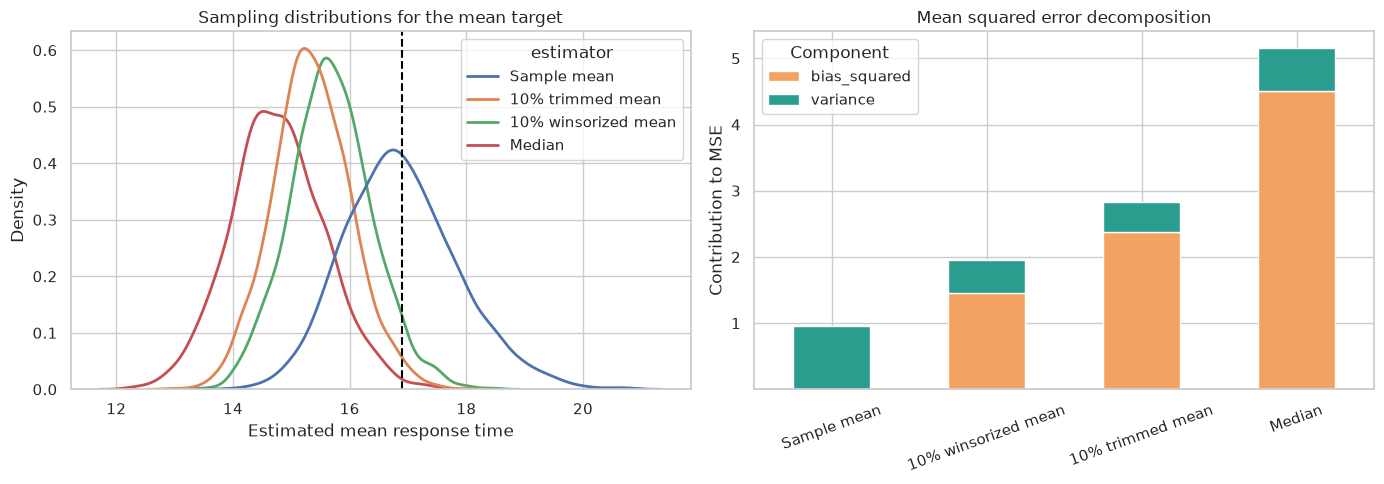

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(
    data=mc_estimates,
    x="estimate",
    hue="estimator",
    common_norm=False,
    fill=False,
    linewidth=2,
    ax=axes[0],
)
axes[0].axvline(true_mean, color="black", linestyle="--", linewidth=1.5)
axes[0].set_title("Sampling distributions for the mean target")
axes[0].set_xlabel("Estimated mean response time")
axes[0].set_ylabel("Density")

decomp = mc_summary[["bias_squared", "sampling_variance"]].rename(columns={"sampling_variance": "variance"})
decomp.plot(kind="bar", stacked=True, ax=axes[1], color=["#f4a261", "#2a9d8f"])
axes[1].set_title("Mean squared error decomposition")
axes[1].set_xlabel("")
axes[1].set_ylabel("Contribution to MSE")
axes[1].legend(title="Component")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


A typical pattern in this kind of operational process is:

- the **sample mean** is close to unbiased for the population mean, but it moves around because rare extreme delays matter;
- the **trimmed** and **winsorized** means are often more stable, but they pay for that stability by downweighting the very outages that genuinely contribute to the mean;
- the **median** can be quite stable, yet it is plainly estimating a different notion of center.

This is the key practical lesson: saying an estimator is "robust" is not enough. Robust to what, and for which target? If your decision depends on expected service-credit cost, the mean is the natural quantity. An estimator that hides expensive tail events may be operationally convenient but strategically misleading.

## 4. Consistency Is Relative to a Target

An estimator is **consistent** for a parameter if it converges to that parameter as sample size grows.

That last phrase matters: **for that parameter**. The trimmed mean is not inconsistent in some vague universal sense. It is inconsistent for the *untrimmed population mean*, but consistent for the *trimmed population mean*.

We will show three curves:

1. sample mean evaluated against the population mean;
2. trimmed mean evaluated against the population mean;
3. trimmed mean evaluated against the trimmed population mean.

,comparison,n,average_estimate,bias,rmse,sampling_sd
0,Sample mean vs population mean,25,16.8454,-0.0463,2.1380,2.1384
1,10% trimmed mean vs population mean,25,15.5811,-1.3107,2.0354,1.5579
2,10% trimmed mean vs trimmed population mean,25,15.6240,0.2924,1.6297,1.6039
3,Sample mean vs population mean,50,16.8618,-0.0299,1.4777,1.4780
4,10% trimmed mean vs population mean,50,15.3769,-1.5149,1.8334,1.0331
5,10% trimmed mean vs trimmed population mean,50,15.3912,0.0596,1.0444,1.0431
6,Sample mean vs population mean,120,16.8922,0.0004,0.9601,0.9605
7,10% trimmed mean vs population mean,120,15.3647,-1.5270,1.6642,0.6618
8,10% trimmed mean vs trimmed population mean,120,15.3436,0.0120,0.6390,0.6391
9,Sample mean vs population mean,400,16.8849,-0.0069,0.5023,0.5025


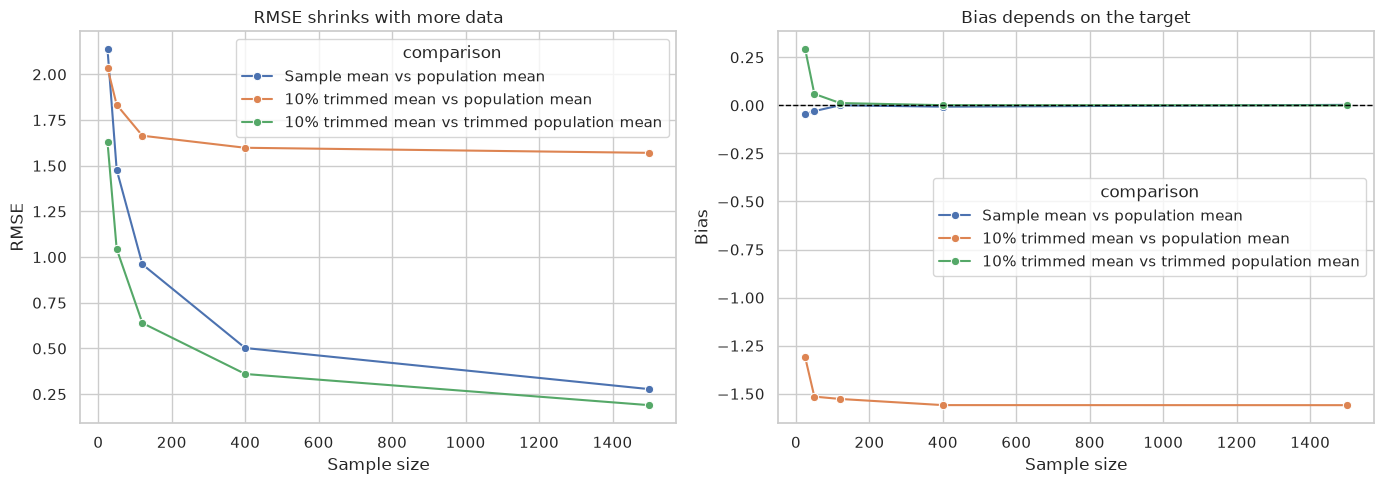

In [6]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
consistency_rng = np.random.default_rng(2050)
sample_sizes = [25, 50, 120, 400, 1500]
consistency_records = []

comparison_setups = [
    ("Sample mean vs population mean", np.mean, true_mean),
    ("10% trimmed mean vs population mean", lambda x: trimmed_mean(x, 0.10), true_mean),
    ("10% trimmed mean vs trimmed population mean", lambda x: trimmed_mean(x, 0.10), true_trimmed_mean),
]

for n in sample_sizes:
    for label, fn, truth in comparison_setups:
        estimates = np.array([fn(consistency_rng.choice(response_values, size=n, replace=True)) for _ in range(1200)])
        consistency_records.append(
            {
                "comparison": label,
                "n": n,
                "average_estimate": estimates.mean(),
                "bias": estimates.mean() - truth,
                "rmse": np.sqrt(np.mean((estimates - truth) ** 2)),
                "sampling_sd": estimates.std(ddof=1),
            }
        )

consistency_summary = pd.DataFrame(consistency_records)
smart_display(consistency_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=consistency_summary, x="n", y="rmse", hue="comparison", marker="o", ax=axes[0])
axes[0].set_title("RMSE shrinks with more data")
axes[0].set_xlabel("Sample size")
axes[0].set_ylabel("RMSE")

sns.lineplot(data=consistency_summary, x="n", y="bias", hue="comparison", marker="o", ax=axes[1])
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Bias depends on the target")
axes[1].set_xlabel("Sample size")
axes[1].set_ylabel("Bias")

plt.tight_layout()
plt.show()


The sample mean should show the classical consistency story: with larger samples, it clusters more tightly around the population mean and its RMSE declines.

The trimmed mean behaves differently depending on the benchmark:

- against the **population mean**, some bias tends to persist even as $n$ grows, because trimming permanently suppresses part of the upper tail;
- against the **trimmed population mean**, that bias should largely disappear, because now the estimator and target agree.

This is one of the most important conceptual checkpoints in statistics: **consistency is not a generic property of an estimator alone; it is a property of an estimator-target pair.**

## 5. Efficiency in a Cleaner World

Efficiency asks a narrower question than MSE. Among estimators aimed at the same parameter, which one has smaller sampling variability?

To make that idea cleaner, we leave the outage-heavy support process for a moment and simulate a much more regular benchmark world. In a roughly symmetric, normal-like environment, the mean, median, and trimmed mean are all trying to summarize the same central location, but they do so with different precision.

This is where the sample mean usually shines.

,average_estimate,bias,sampling_sd,rmse,relative_efficiency_vs_mean
estimator,,,,,
Sample mean,11.9862,-0.0033,0.5545,0.5544,1.0000
10% trimmed mean,11.9908,0.0012,0.5716,0.5715,0.9410
Median,12.0077,0.0182,0.6904,0.6905,0.6451


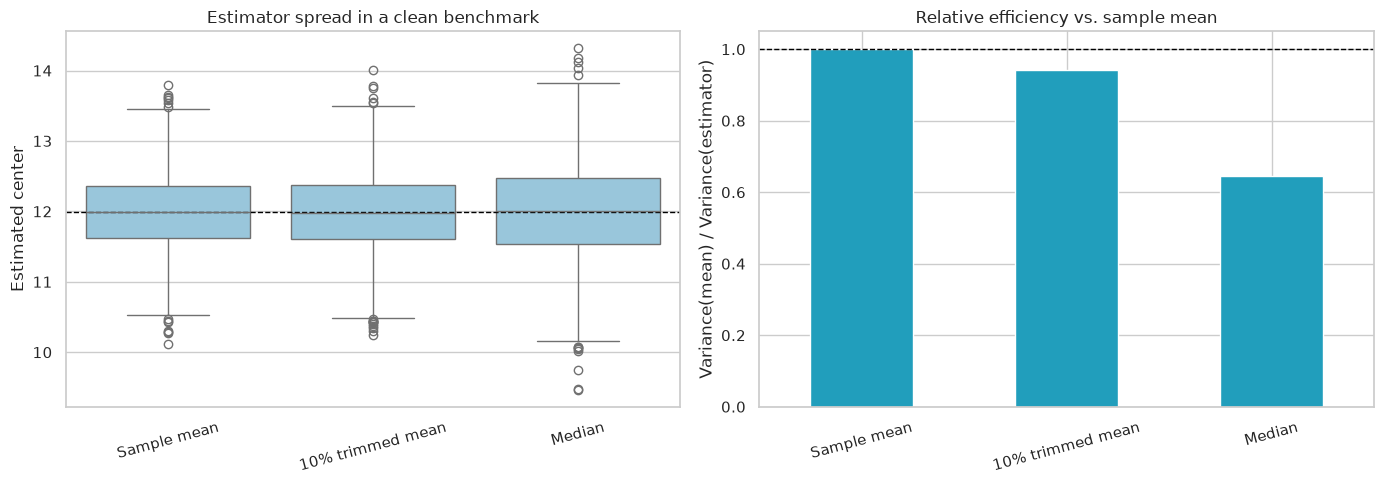

In [7]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
clean_rng = np.random.default_rng(2051)
clean_population = clean_rng.normal(loc=12.0, scale=4.0, size=300_000)
clean_truth = clean_population.mean()

clean_estimators = {
    "Sample mean": np.mean,
    "10% trimmed mean": lambda x: trimmed_mean(x, 0.10),
    "Median": np.median,
}

clean_mc = monte_carlo_estimates(clean_population, n=50, reps=2500, rng=np.random.default_rng(2052), estimator_map=clean_estimators)
clean_summary = summarize_estimators(clean_mc, truth=clean_truth)
variance_mean = clean_summary.loc["Sample mean", "sampling_variance"]
clean_summary["relative_efficiency_vs_mean"] = variance_mean / clean_summary["sampling_variance"]

smart_display(clean_summary[["average_estimate", "bias", "sampling_sd", "rmse", "relative_efficiency_vs_mean"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=clean_mc, x="estimator", y="estimate", ax=axes[0], color="#8ecae6")
axes[0].axhline(clean_truth, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Estimator spread in a clean benchmark")
axes[0].set_xlabel("")
axes[0].set_ylabel("Estimated center")
axes[0].tick_params(axis="x", rotation=15)

clean_summary["relative_efficiency_vs_mean"].plot(kind="bar", ax=axes[1], color="#219ebc")
axes[1].set_title("Relative efficiency vs. sample mean")
axes[1].set_xlabel("")
axes[1].set_ylabel("Variance(mean) / Variance(estimator)")
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


In a clean symmetric world, the sample mean is usually the most efficient of these common center estimators. That is not because the mean is morally superior. It is because its design matches the data-generating conditions.

This gives a healthy corrective to simplistic robustness slogans. The trimmed mean or median can be preferable in contaminated settings, but when the benchmark assumptions are approximately right, the ordinary sample mean wastes the least information.

So estimator choice is always conditional on the world you think generated the data.

## 6. Stabilized Estimators for Small Team Dashboards

Estimating an overall mean is one task. Ranking many small teams is another.

If one queue handled only a few dozen tickets this month and another handled a few hundred, the raw breach-rate estimates will not be equally stable. Small groups can look spectacular or disastrous just because of noise.

A simple stabilized estimator uses shrinkage toward an overall rate:

$$
\hat{p}_i^{\mathrm{shrunk}} = \frac{y_i + \alpha}{n_i + \alpha + \beta}
$$

where $y_i$ is the number of breaches, $n_i$ is the ticket count, and $(\alpha, \beta)$ encode a prior center. This introduces bias toward the portfolio average, but can sharply reduce noise for tiny groups.

That is still the bias-variance tradeoff, now in dashboard form.

In [8]:
# Simulate data or resample observations to study variability and uncertainty.
team_truth = (
    population.groupby("team")
    .agg(true_breach_rate=("sla_breach", "mean"), population_share=("team", "size"))
    .reset_index()
)
team_truth["population_share"] = team_truth["population_share"] / team_truth["population_share"].sum()

monthly_n = np.maximum(
    18,
    np.round(15 + 1800 * team_truth["population_share"] + rng.normal(0, 15, size=len(team_truth))).astype(int),
)
observed_breaches = rng.binomial(monthly_n, team_truth["true_breach_rate"])

overall_breach_rate = population["sla_breach"].mean()
prior_strength = 40
alpha_prior = overall_breach_rate * prior_strength
beta_prior = (1 - overall_breach_rate) * prior_strength

team_month = team_truth.copy()
team_month["n_tickets"] = monthly_n
team_month["breaches"] = observed_breaches
team_month["raw_rate"] = team_month["breaches"] / team_month["n_tickets"]
team_month["shrunk_rate"] = (team_month["breaches"] + alpha_prior) / (team_month["n_tickets"] + alpha_prior + beta_prior)
team_month["weight_on_raw"] = team_month["n_tickets"] / (team_month["n_tickets"] + prior_strength)
team_month["raw_abs_error"] = np.abs(team_month["raw_rate"] - team_month["true_breach_rate"])
team_month["shrunk_abs_error"] = np.abs(team_month["shrunk_rate"] - team_month["true_breach_rate"])

stabilization_summary = pd.DataFrame(
    [
        {
            "overall true breach rate": overall_breach_rate,
            "mean absolute error of raw team rates": team_month["raw_abs_error"].mean(),
            "mean absolute error of shrunk team rates": team_month["shrunk_abs_error"].mean(),
            "smallest team size": team_month["n_tickets"].min(),
            "largest team size": team_month["n_tickets"].max(),
        }
    ]
)

smart_display(stabilization_summary)
smart_display(
    team_month.nsmallest(6, "n_tickets")[[
        "team",
        "n_tickets",
        "true_breach_rate",
        "raw_rate",
        "shrunk_rate",
        "weight_on_raw",
    ]]
)


,overall true breach rate,mean absolute error of raw team rates,mean absolute error of shrunk team rates,smallest team size,largest team size
0,0.4860,0.0465,0.0357,33,223


,team,n_tickets,true_breach_rate,raw_rate,shrunk_rate,weight_on_raw
14,Queue 15,33,0.5065,0.6364,0.5540,0.4521
15,Queue 16,41,0.3910,0.4146,0.4499,0.5062
13,Queue 14,58,0.5550,0.5690,0.5351,0.5918
12,Queue 13,68,0.4887,0.4412,0.4578,0.6296
9,Queue 10,87,0.4950,0.4598,0.4680,0.6850
10,Queue 11,91,0.4640,0.3407,0.3850,0.6947


The useful information is what the average hides. Variability, skew, and tail exposure can make two options with similar means very different from a staffing, service, or budget perspective.


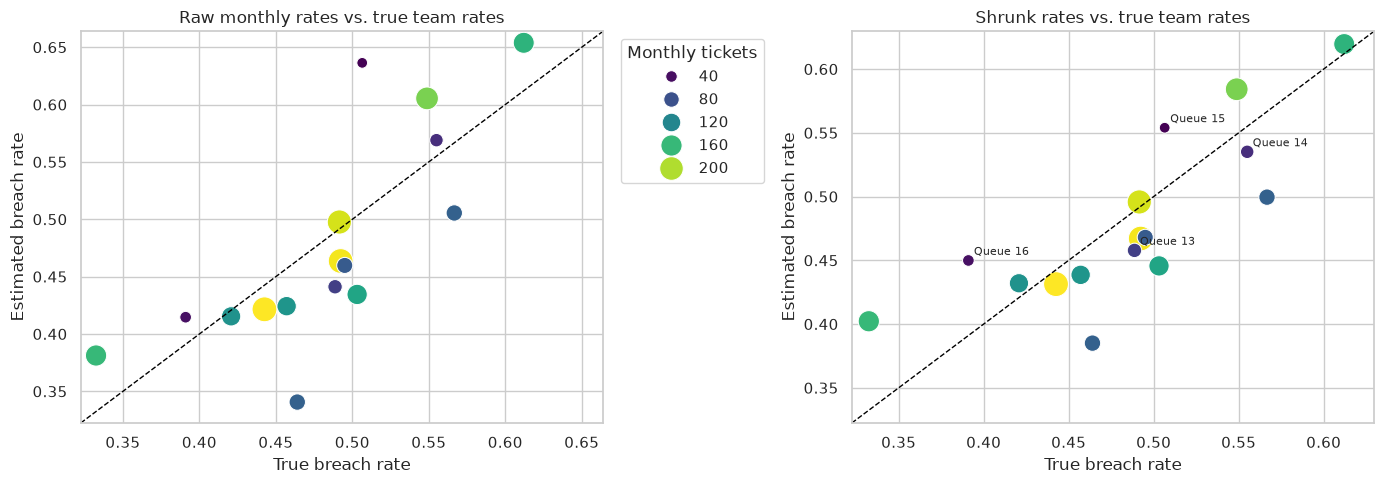

In [9]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, column, title in [
    (axes[0], "raw_rate", "Raw monthly rates vs. true team rates"),
    (axes[1], "shrunk_rate", "Shrunk rates vs. true team rates"),
]:
    sns.scatterplot(
        data=team_month,
        x="true_breach_rate",
        y=column,
        size="n_tickets",
        sizes=(60, 320),
        hue="n_tickets",
        palette="viridis",
        legend="brief" if column == "raw_rate" else False,
        ax=ax,
    )
    lim_min = min(team_month["true_breach_rate"].min(), team_month[column].min()) - 0.01
    lim_max = max(team_month["true_breach_rate"].max(), team_month[column].max()) + 0.01
    ax.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--", color="black", linewidth=1)
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.set_title(title)
    ax.set_xlabel("True breach rate")
    ax.set_ylabel("Estimated breach rate")

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend(handles, labels, title="Monthly tickets", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

for _, row in team_month.nsmallest(4, "n_tickets").iterrows():
    axes[1].annotate(row["team"], (row["true_breach_rate"], row["shrunk_rate"]), textcoords="offset points", xytext=(4, 4), fontsize=8)

plt.tight_layout()
plt.show()


Shrinkage is often exactly what a responsible dashboard needs. It acknowledges that small samples are noisy and should not be read at face value. In the scatterplots, larger and brighter points correspond to teams with more monthly tickets, so the volume signal is visible in the plot.

The tradeoff is transparent.

- **raw rates** are unbiased in expectation for each team, but can be erratic when monthly volume is low;
- **shrunk rates** pull small teams toward the portfolio average, creating some bias but often reducing overall estimation error and improving ranking stability.

This is why empirical-Bayes and related stabilization ideas remain so influential in applied analytics. They do not eliminate uncertainty. They express it in a more decision-appropriate way.

## Wrap-Up

We developed the core language of estimators through a decision-science lens:

1. A parameter, an estimator, and an estimate are not the same object.
2. Low variance is not enough if the estimator is aimed at the wrong target.
3. Mean squared error combines bias and variance into a single decision-relevant score.
4. Consistency is always relative to a target parameter.
5. Efficiency matters when competing estimators genuinely target the same quantity.
6. Small-group dashboards often benefit from stabilized estimators that trade a little bias for much less noise.

The next notebook will build naturally from here: once we have an estimator, how do we communicate its uncertainty with intervals and a point estimate together?

## References

- Efron, B. (1979). *Bootstrap methods: Another look at the jackknife*. *The Annals of Statistics, 7*(1). [https://doi.org/10.1214/aos/1176344552](https://doi.org/10.1214/aos/1176344552)
- Efron, B., & Morris, C. N. (1975). *Data analysis using Stein's estimator and its generalizations*. *Journal of the American Statistical Association, 70*(350), 311-319. [https://doi.org/10.1080/01621459.1975.10479864](https://doi.org/10.1080/01621459.1975.10479864)
- Geman, S., Bienenstock, E., & Doursat, R. (1992). *Neural networks and the bias/variance dilemma*. *Neural Computation, 4*(1), 1-58. [https://doi.org/10.1162/neco.1992.4.1.1](https://doi.org/10.1162/neco.1992.4.1.1)
- Tukey, J. W. (1962). *The future of data analysis*. *The Annals of Mathematical Statistics, 33*(1), 1-67. [https://doi.org/10.1214/aoms/1177704711](https://doi.org/10.1214/aoms/1177704711)
- Tversky, A., & Kahneman, D. (1971). *Belief in the law of small numbers*. *Psychological Bulletin, 76*(2), 105-110. [https://doi.org/10.1037/h0031322](https://doi.org/10.1037/h0031322)
